# Startup Founder Burnout Analysis 2026
## Part 1: Exploratory Data Analysis




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats

In [2]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

In [4]:
df = pd.read_csv('/content/startup_founder_burnout_2026.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (50000, 29)


,Founder_Type,Economic_Climate,Founder_Age,Founder_Experience_Years,Industry,Funding_Stage,Work_Mode,Team_Size,Startup_Age_Months,Weekly_Work_Hours,...,Founder_Burnout_Flag,Monthly_Revenue_Growth_Percent,Runway_Months_Remaining,Product_Market_Fit_Score,Employee_Turnover_Percent,Work_Life_Balance_Score,Seeks_Mental_Health_Support,Shutdown_Probability,Shutdown_Risk,Startup_Failure_Flag
0,Serial Entrepreneur,Recession,31,12,E-commerce,Seed,Remote,14,99,48.5,...,0,-5.1,5.6,7.8,30.0,9.7,No,0.082,Low,0
1,Calm Operator,Recession,30,0,FinTech,Bootstrapped,Remote,6,47,48.6,...,0,2.7,8.4,2.3,14.4,10.0,No,0.490,Medium,0
2,Burned-Out Operator,Stable Economy,28,3,ClimateTech,Bootstrapped,Hybrid,5,59,68.8,...,0,16.3,4.4,1.0,41.5,4.0,No,0.905,High,1
3,Chaotic Innovator,Stable Economy,32,2,EdTech,Series A,Office,74,143,81.5,...,0,-1.4,31.5,4.0,39.4,5.1,No,0.233,Low,0
4,Growth Obsessed Founder,Stable Economy,35,1,SaaS,Pre-Seed,Hybrid,9,11,78.6,...,0,21.6,7.0,5.2,36.5,4.2,No,0.716,High,1


In [6]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Founder_Type                    50000 non-null  object 
 1   Economic_Climate                50000 non-null  object 
 2   Founder_Age                     50000 non-null  int64  
 3   Founder_Experience_Years        50000 non-null  int64  
 4   Industry                        50000 non-null  object 
 5   Funding_Stage                   50000 non-null  object 
 6   Work_Mode                       50000 non-null  object 
 7   Team_Size                       50000 non-null  int64  
 8   Startup_Age_Months              50000 non-null  int64  
 9   Weekly_Work_Hours               50000 non-null  float64
 10  Sleep_Hours                     50000 non-null  float64
 11  Exercise_Days_Per_Week          50000 non-null  float64
 12  Vacation_Days_Taken             

In [10]:
print(df.isnull().sum().sum())

0


In [11]:
df.describe()

,Founder_Age,Founder_Experience_Years,Team_Size,Startup_Age_Months,Weekly_Work_Hours,Sleep_Hours,Exercise_Days_Per_Week,Vacation_Days_Taken,Investor_Pressure_Score,Cofounder_Conflict_Score,...,Decision_Fatigue_Score,Burnout_Score,Founder_Burnout_Flag,Monthly_Revenue_Growth_Percent,Runway_Months_Remaining,Product_Market_Fit_Score,Employee_Turnover_Percent,Work_Life_Balance_Score,Shutdown_Probability,Startup_Failure_Flag
count,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.116580,2.62538,54.708660,72.630640,63.703472,5.690506,3.756374,9.256180,6.135680,4.012498,...,4.506346,3.439614,0.107880,5.540454,12.392214,5.330516,35.855618,6.742784,0.386161,0.237340
std,6.503577,2.10280,112.424631,41.044886,13.160604,1.008238,1.298077,6.514507,2.223854,2.334365,...,2.586042,2.229828,0.310232,14.459565,6.310302,2.406663,16.482813,2.745858,0.296182,0.425457
min,21.000000,0.00000,1.000000,2.000000,28.000000,2.800000,0.000000,0.000000,1.000000,0.000000,...,1.000000,1.000000,0.000000,-45.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000
25%,30.000000,1.00000,6.000000,37.000000,54.700000,5.000000,2.900000,4.100000,4.600000,2.300000,...,2.300000,1.200000,0.000000,-3.500000,7.800000,3.600000,23.800000,4.700000,0.118000,0.000000
50%,34.000000,2.00000,16.000000,73.000000,63.600000,5.700000,3.700000,8.900000,6.200000,4.000000,...,4.200000,3.100000,0.000000,4.000000,12.300000,5.300000,35.000000,7.100000,0.318000,0.000000
75%,39.000000,4.00000,54.000000,108.000000,72.600000,6.400000,4.600000,13.700000,7.800000,5.600000,...,6.400000,5.000000,0.000000,14.500000,16.700000,7.100000,47.000000,9.300000,0.633000,0.000000
max,61.000000,12.00000,799.000000,143.000000,110.000000,9.000000,7.000000,35.000000,10.000000,10.000000,...,10.000000,10.000000,1.000000,74.700000,36.000000,10.000000,97.600000,10.000000,0.998000,1.000000


In [13]:
df.shape

(50000, 29)

In [14]:
print(df['Burnout_Level'].value_counts(normalize=True) * 100)

Burnout_Level
Low         55.826
Moderate    33.386
Severe      10.788
Name: proportion, dtype: float64


In [15]:
print("\nBurnout Flag Distribution:")
print(df['Founder_Burnout_Flag'].value_counts(normalize=True) * 100)


Burnout Flag Distribution:
Founder_Burnout_Flag
0    89.212
1    10.788
Name: proportion, dtype: float64


## 1. Burnout Level Distribution

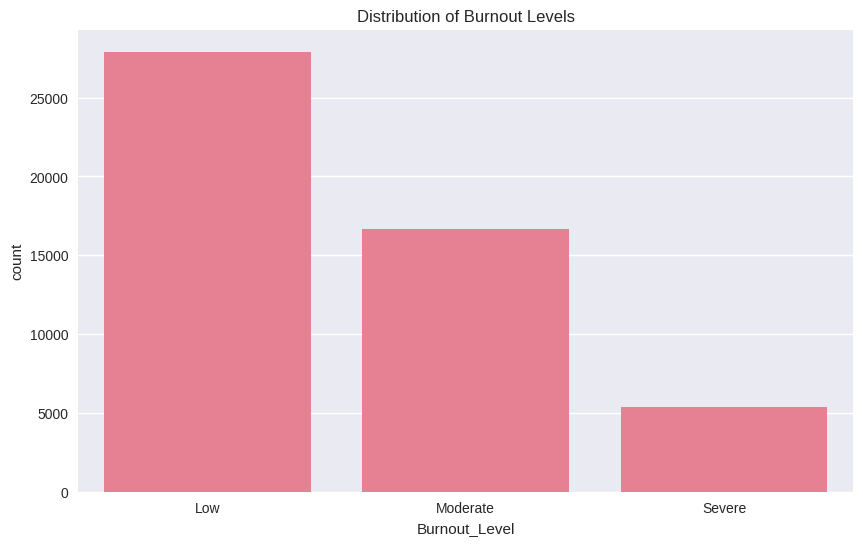

In [16]:

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Burnout_Level', order=['Low', 'Moderate', 'Severe'])
plt.title('Distribution of Burnout Levels')
plt.show()

## 2. Burnout by Founder Type


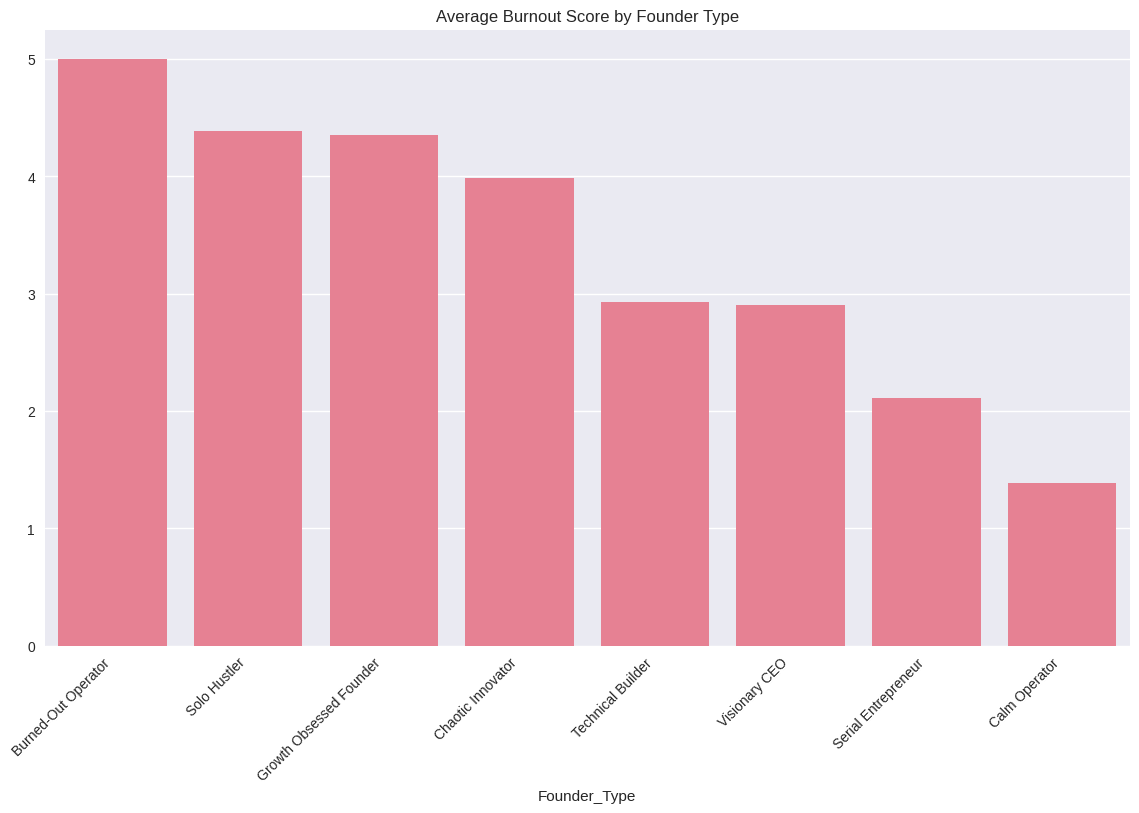

In [17]:

plt.figure(figsize=(14,8))
burnout_by_type = df.groupby('Founder_Type')['Burnout_Score'].mean().sort_values(ascending=False)
sns.barplot(x=burnout_by_type.index, y=burnout_by_type.values)
plt.xticks(rotation=45, ha='right')
plt.title('Average Burnout Score by Founder Type')
plt.show()

## 3. Correlation Heatmap (Key Features)

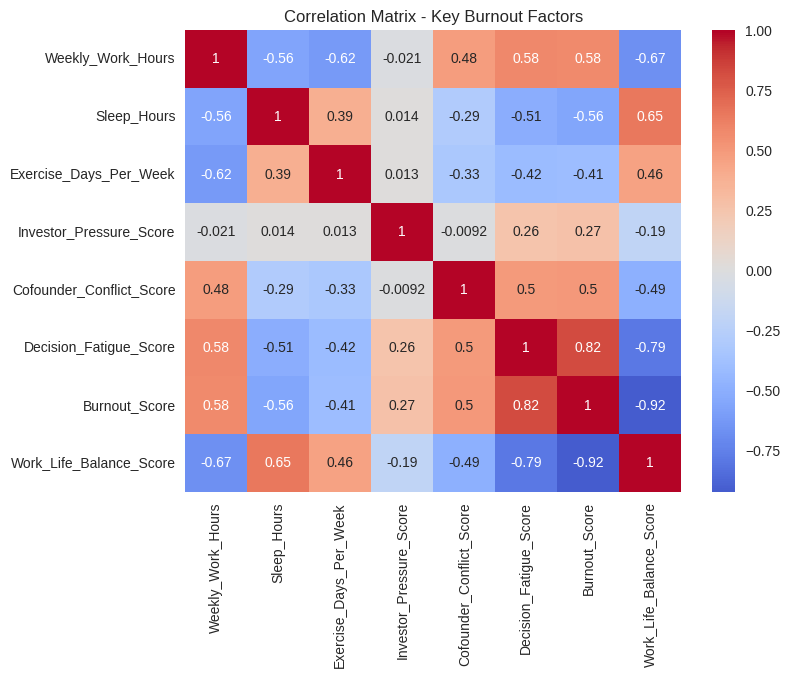

In [19]:

key_features = ['Weekly_Work_Hours', 'Sleep_Hours', 'Exercise_Days_Per_Week',
                'Investor_Pressure_Score', 'Cofounder_Conflict_Score',
                'Decision_Fatigue_Score', 'Burnout_Score', 'Work_Life_Balance_Score']

plt.figure(figsize=(8,6))
corr = df[key_features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Key Burnout Factors')
plt.show()

## 4. Work Hours vs Burnout

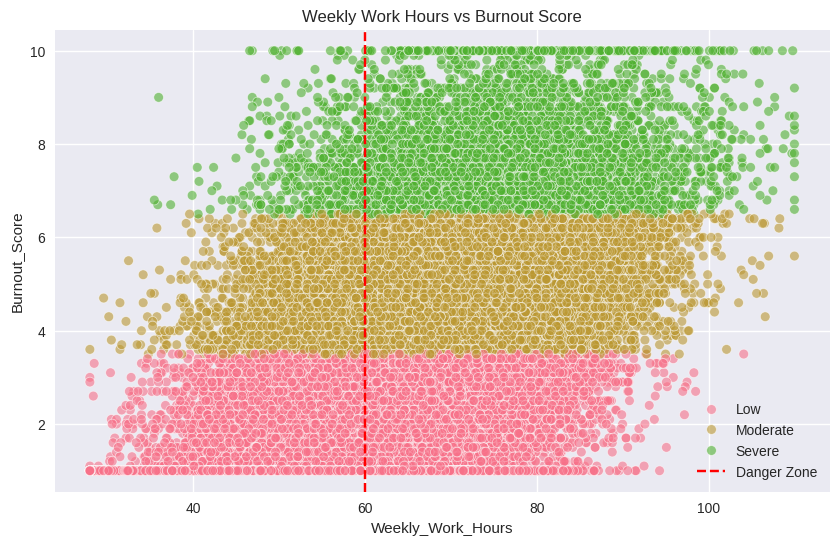

In [20]:

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Weekly_Work_Hours', y='Burnout_Score', hue='Burnout_Level', alpha=0.6)
plt.title('Weekly Work Hours vs Burnout Score')
plt.axvline(x=60, color='red', linestyle='--', label='Danger Zone')
plt.legend()
plt.show()

## 5. Burnout by Funding Stage & Work Mode

In [22]:
# 5. Burnout by Funding Stage & Work Mode
plt.figure(figsize=(10,6))
fig = px.box(df, x='Funding_Stage', y='Burnout_Score', color='Work_Mode',
             title="Burnout Score by Funding Stage and Work Mode")
fig.show()

<Figure size 1000x600 with 0 Axes>